# 01 — EDA: Water Potability (dataset crudo)

Exploración del dataset crudo `data/raw/water_potability.csv`, tal como se descargó de Kaggle,
sin ninguna transformación. Objetivo: confirmar shape, columnas, valores faltantes esperados
(pH: 491 NaN, Sulfato: 781 NaN, Trihalometanos: 162 NaN) y el desbalance de clases (~60/40)
descritos en el enunciado (Parte 1).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

RAW_PATH = ROOT / "data" / "raw" / "water_potability.csv"
df = pd.read_csv(RAW_PATH)
df.shape

(3276, 10)

In [2]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
df.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

## Valores faltantes

El enunciado espera: pH 491 NaN, Sulfato 781 NaN, Trihalometanos 162 NaN.

In [4]:
missing = df.isna().sum()
missing[missing > 0]

ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

## Balance de clases

El enunciado indica una distribución original aproximada de 60% no potable / 40% potable.

In [5]:
counts = df["Potability"].value_counts()
proportions = df["Potability"].value_counts(normalize=True).round(3)
pd.DataFrame({"count": counts, "proportion": proportions})

,count,proportion
Potability,,
0,1998,0.61
1,1278,0.39


C:\Users\320306380\AppData\Local\Temp\ipykernel_16012\1008388305.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No potable (0)", "Potable (1)"])


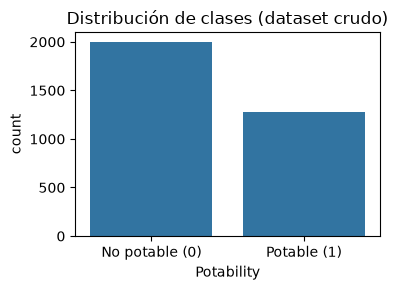

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x="Potability", data=df, ax=ax)
ax.set_xticklabels(["No potable (0)", "Potable (1)"])
ax.set_title("Distribución de clases (dataset crudo)")
fig.tight_layout()
plt.show()

## Estadísticas descriptivas de las 9 features fisicoquímicas

In [7]:
FEATURES = [
    "ph", "Hardness", "Solids", "Chloramines", "Sulfate",
    "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity",
]
df[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000


## Distribuciones por feature, separadas por clase

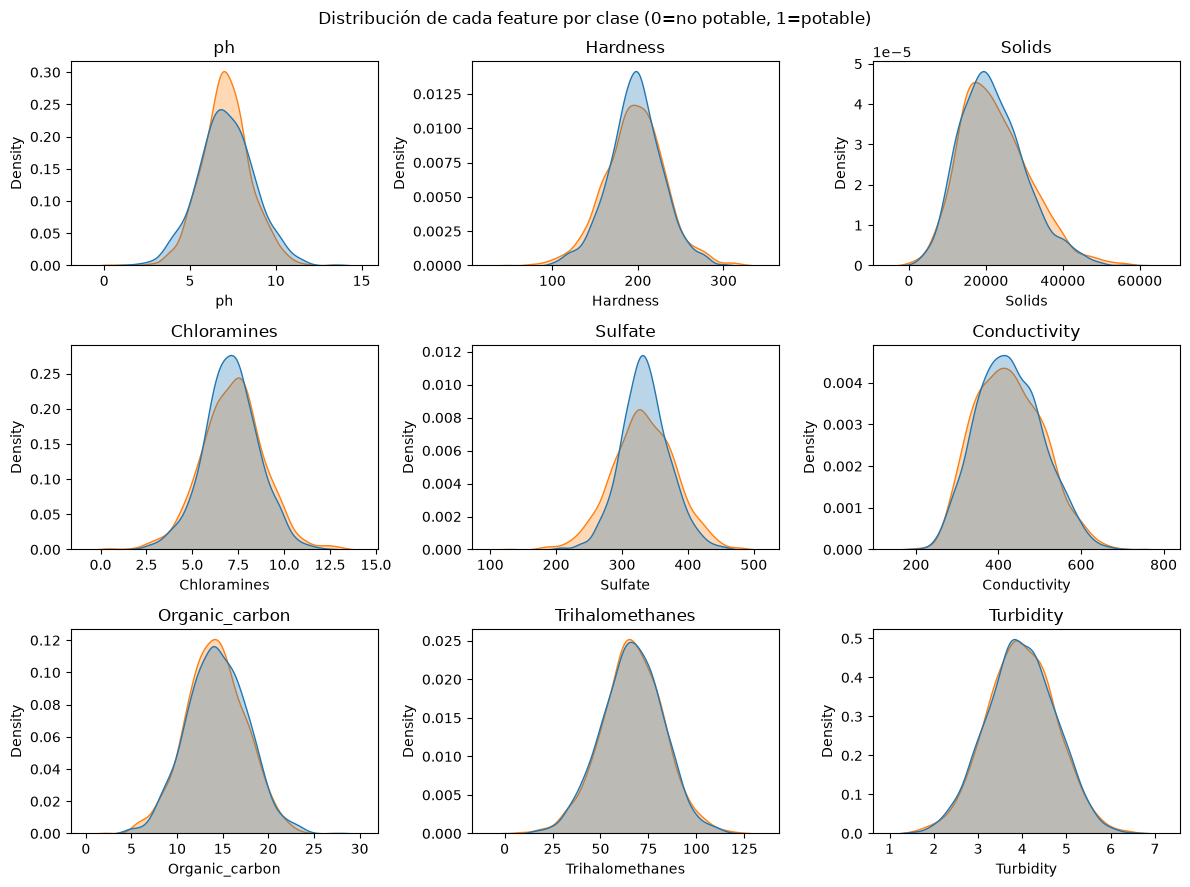

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.kdeplot(data=df, x=col, hue="Potability", ax=ax, common_norm=False, fill=True, alpha=0.3, legend=False)
    ax.set_title(col)
fig.suptitle("Distribución de cada feature por clase (0=no potable, 1=potable)")
fig.tight_layout()
plt.show()

## Correlación entre features

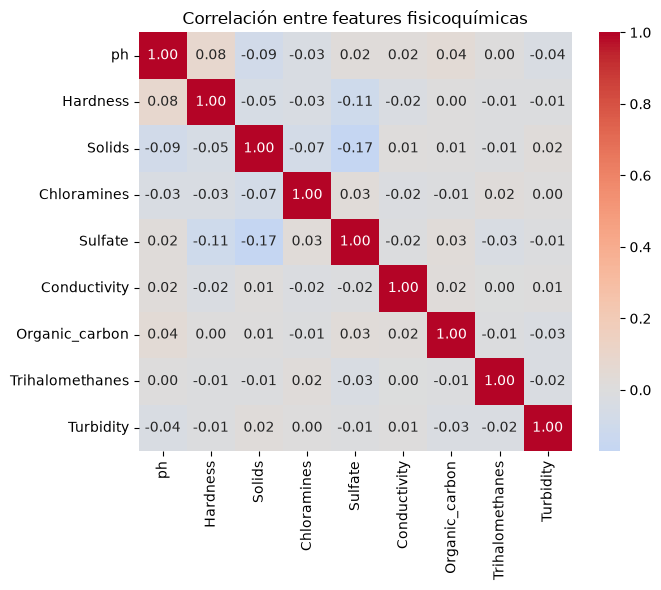

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre features fisicoquímicas")
fig.tight_layout()
plt.show()

## Conclusiones de esta EDA

- Confirmar aquí (tras ejecutar) que los conteos de NaN y el balance de clases coinciden con lo
  esperado por el enunciado.
- Las features no muestran correlaciones fuertes entre sí a simple vista — no hay redundancia
  obvia que justifique eliminar columnas antes del pipeline de `src/data_prep/`.
- Siguiente paso: `02_classical_baseline.ipynb`, que llama al pipeline de `src/data_prep/` y a la
  línea base de `src/classical/`.